## 1. Import Libraries

In [78]:

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
import joblib
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

In [37]:
# !unzip creditcard.csv.zip

## 2. Load Dataset

In [38]:
# Load data
df = pd.read_csv('/content/creditcard.csv')
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


In [39]:
# Display first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [40]:
# Display last rows
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 3. Initial Data Exploration

In [41]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [42]:
# Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [43]:
# Column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [44]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


## 4. Missing Values Analysis

In [45]:
# Check missing values
print("Missing Values Count:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Missing Values Count:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values: 0


## 5. Duplicate Records Analysis

In [46]:
# Check duplicates
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")

Number of Duplicate Rows: 1081


## 6. Target Variable Analysis

In [47]:
# Target variable distribution
print("Target Variable Distribution:")
print(df['Class'].value_counts())

Target Variable Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [48]:
# Target variable percentage
print("Target Variable Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Target Variable Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### we will handle class imbalance while model training

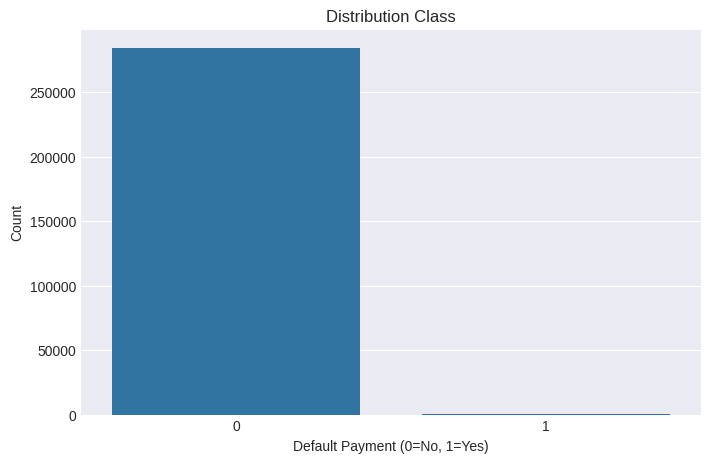

In [51]:
# Visualize target variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class')
plt.title('Distribution Class')
plt.xlabel('Default Payment (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

## 8. Univariate Analysis

In [55]:
numerical_cols=df.select_dtypes("number")
numerical_cols

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


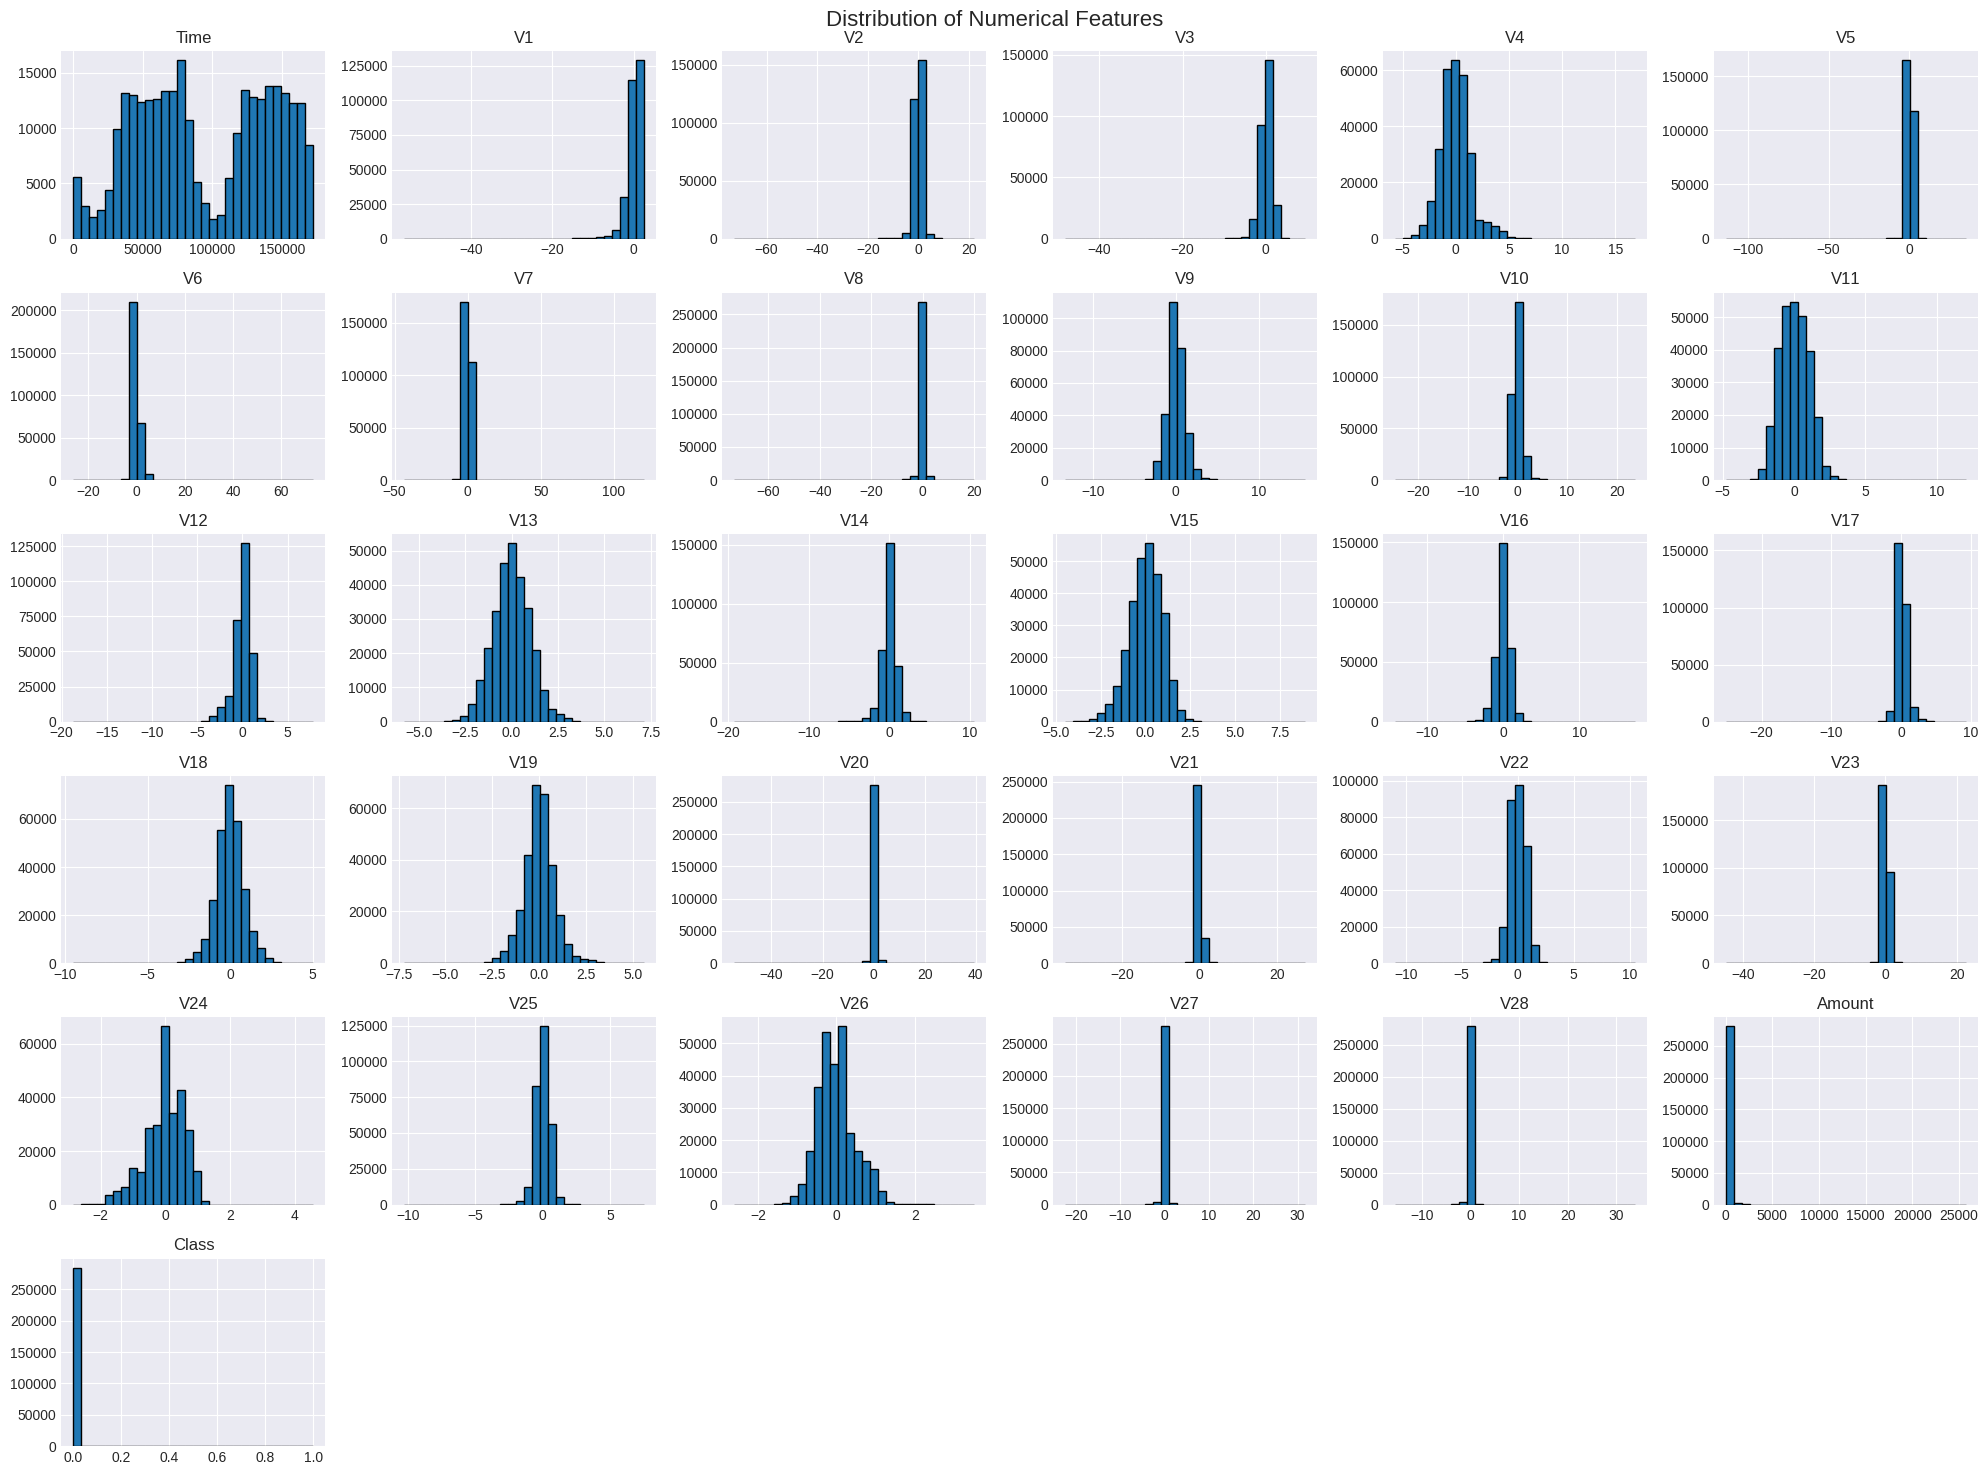

In [52]:
# Distribution of numerical features
df.hist(bins=30, figsize=(20, 15), edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

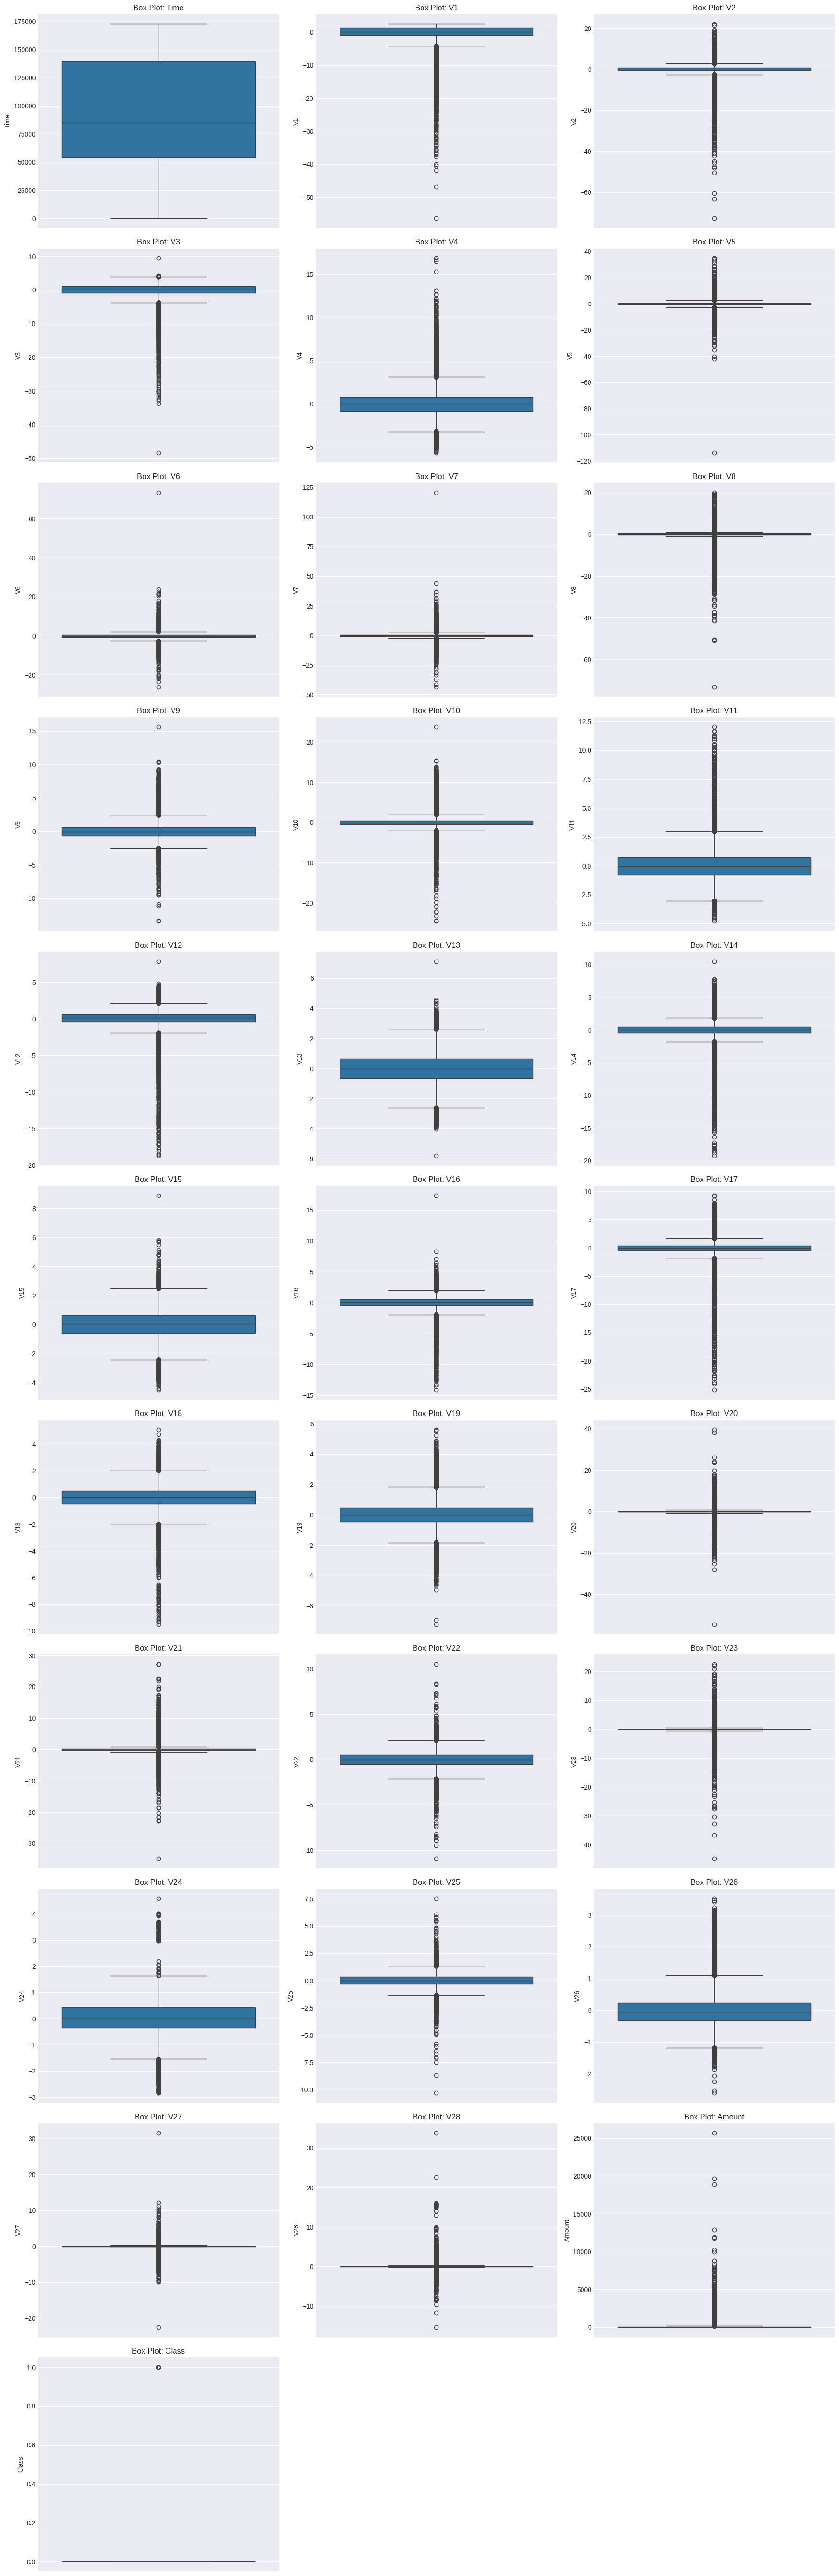

In [57]:
# Box plots for numerical features
num_cols = len(numerical_cols.columns)
num_rows = (num_cols + 2) // 3  # Calculate number of rows needed for 3 columns

fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5 * num_rows))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols.columns):
    sns.boxplot(data=df, y=col, ax=axes[idx])
    axes[idx].set_title(f'Box Plot: {col}')

# Hide any unused subplots
for i in range(num_cols, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 10. Correlation Analysis

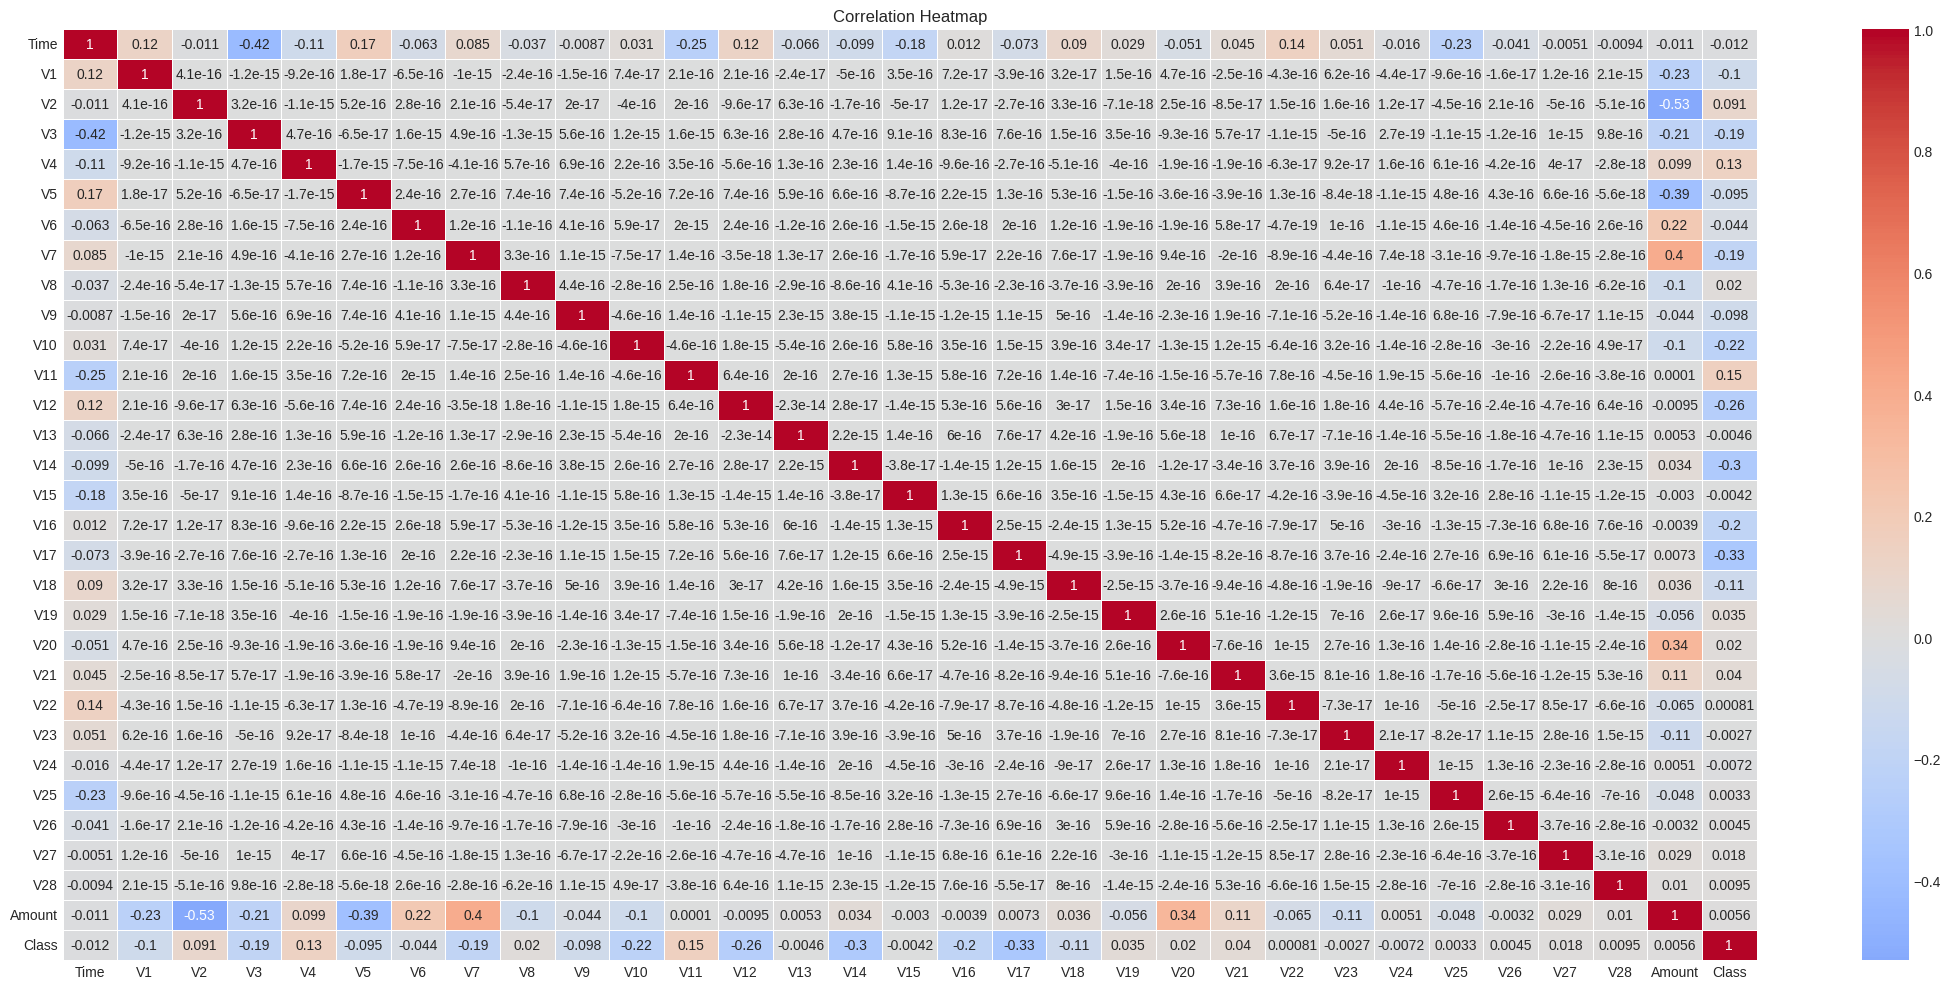

In [61]:
# Correlation matrix
plt.figure(figsize=(22, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [62]:
# Correlation with target variable
target_corr = df.corr()['Class'].sort_values(ascending=False)
print("Correlation with Target Variable:")
print(target_corr)

Correlation with Target Variable:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


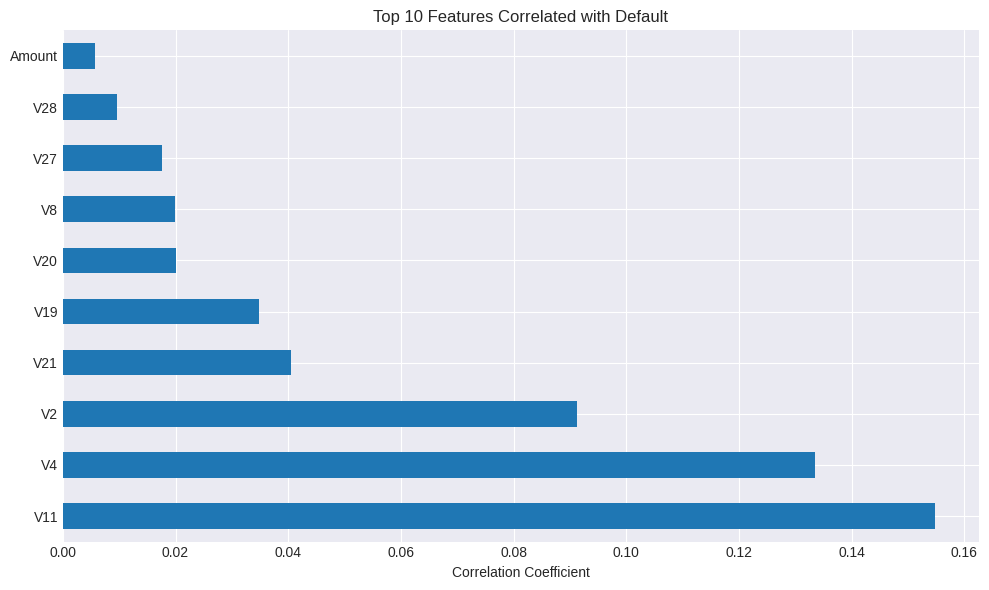

In [63]:
# Visualize top correlations with target
top_corr = target_corr[1:11]  # Exclude target itself
plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh')
plt.title('Top 10 Features Correlated with Default')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## 11. Outlier Detection

In [64]:
# Detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

In [65]:
# Outlier analysis for numerical features
print("Outlier Analysis:")
for col in numerical_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col}: {count} outliers ({count/len(df)*100:.2f}%)")

Outlier Analysis:
Time: 0 outliers (0.00%)
V1: 7062 outliers (2.48%)
V2: 13526 outliers (4.75%)
V3: 3363 outliers (1.18%)
V4: 11148 outliers (3.91%)
V5: 12295 outliers (4.32%)
V6: 22965 outliers (8.06%)
V7: 8948 outliers (3.14%)
V8: 24134 outliers (8.47%)
V9: 8283 outliers (2.91%)
V10: 9496 outliers (3.33%)
V11: 780 outliers (0.27%)
V12: 15348 outliers (5.39%)
V13: 3368 outliers (1.18%)
V14: 14149 outliers (4.97%)
V15: 2894 outliers (1.02%)
V16: 8184 outliers (2.87%)
V17: 7420 outliers (2.61%)
V18: 7533 outliers (2.64%)
V19: 10205 outliers (3.58%)
V20: 27770 outliers (9.75%)
V21: 14497 outliers (5.09%)
V22: 1317 outliers (0.46%)
V23: 18541 outliers (6.51%)
V24: 4774 outliers (1.68%)
V25: 5367 outliers (1.88%)
V26: 5596 outliers (1.96%)
V27: 39163 outliers (13.75%)
V28: 30342 outliers (10.65%)
Amount: 31904 outliers (11.20%)
Class: 492 outliers (0.17%)


## 13. Data Preprocessing - Handle Invalid Values

In [66]:
# Create copy for preprocessing
df_clean = df.copy()

In [68]:
scaler = StandardScaler()
df_clean[['Amount', 'Time']] = scaler.fit_transform(df_clean[['Amount', 'Time']])

In [69]:
# 2. Feature Engineering: Log-transform Amount and extract Hour from Time
df_clean['LOG_AMOUNT'] = np.log1p(df_clean['Amount'])
df_clean['HOUR'] = (df_clean['Time'] * scaler.scale_[1] + scaler.mean_[1]) // 3600 % 24  # Convert back to seconds, then extract hour



In [70]:

X = df_clean.drop(['Class'], axis=1)
y = df_clean['Class']

## 15. Model Training with Pipelines
We will train multiple models (tree-based and regression) using sklearn Pipelines, including preprocessing and handling class imbalance. Each model's evaluation metrics will be printed after training.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
models = {
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train == 0).sum()/(y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}


In [79]:
# 2. Preprocessing with ColumnTransformer
num_features = X.columns.tolist()
preprocessor = ColumnTransformer([('num', StandardScaler(), num_features)])

In [ ]:
results = []

for name, model in models.items():
    pipe = ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else None
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc})
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall: {rec:.4f}')
    print(f'F1-Score: {f1:.4f}')
    if roc is not None:
        print(f'ROC-AUC: {roc:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(10,6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    if metric in results_df.columns and results_df[metric].notnull().all():
        plt.plot(results_df['Model'], results_df[metric], marker='o', label=metric)

plt.title('Model Comparison Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
for name, model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps['clf'], 'predict_proba') else None
    print(f'\n=== {name} ===')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred):.4f}')
    print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
    if y_proba is not None:
        print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

## 16. Model Selection, Tuning, and ANN
We will select the best classical model, tune it, build and train an ANN using TensorFlow, plot training curves, compare all models, and save the best model and scaler.

In [ ]:
# 1. Select best classical model based on ROC-AUC

best_model_name = max(results, key=lambda x: x['ROC-AUC'] if x['ROC-AUC'] is not None else 0)['Model']
print(f'Best classical model: {best_model_name}')

# 2. Hyperparameter tuning for best model (example: Random Forest)

if best_model_name == 'Random Forest':
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [10, 20],
        'clf__min_samples_split': [2, 5]
    }
    model = RandomForestClassifier(class_weight='balanced', random_state=42)
elif best_model_name == 'XGBoost':
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 6],
        'clf__learning_rate': [0.01, 0.1]
    }
    model = XGBClassifier(scale_pos_weight=(y_train == 0).sum()/(y_train == 1).sum(), use_label_encoder=False, eval_metric='logloss', random_state=42)
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 6],
        'clf__learning_rate': [0.01, 0.1]
    }
    model = GradientBoostingClassifier(random_state=42)
elif best_model_name == 'AdaBoost':
    param_grid = {
        'clf__n_estimators': [50, 100],
        'clf__learning_rate': [0.01, 0.1, 1.0]
    }
    model = AdaBoostClassifier(random_state=42)
else:
    param_grid = {
        'clf__C': [0.1, 1, 10]
    }
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

from imblearn.pipeline import Pipeline as ImbPipeline

tune_pipe = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', model)
    ])


In [ ]:

grid = GridSearchCV(tune_pipe, param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best ROC-AUC: {grid.best_score_:.4f}')

# Evaluate tuned model
y_pred_tuned = grid.predict(X_test)
y_proba_tuned = grid.predict_proba(X_test)[:, 1] if hasattr(grid.best_estimator_.named_steps['clf'], 'predict_proba') else None
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
print('\n=== Tuned Model Evaluation ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_tuned):.4f}')
if y_proba_tuned is not None:
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_tuned))

# Add tuned model to results for comparison
results.append({'Model': f'Tuned {best_model_name}', 'Accuracy': accuracy_score(y_test, y_pred_tuned), 'Precision': precision_score(y_test, y_pred_tuned), 'Recall': recall_score(y_test, y_pred_tuned), 'F1-Score': f1_score(y_test, y_pred_tuned), 'ROC-AUC': roc_auc_score(y_test, y_proba_tuned) if y_proba_tuned is not None else None})

## Build ANN model

In [ ]:
scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann = scaler_ann.transform(X_test)

# Build ANN model
ann = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_ann.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train ANN model
history = ann.fit(X_train_ann, y_train, epochs=20, batch_size=2048, validation_data=(X_test_ann, y_test), verbose=2)

# Evaluate ANN
ann_loss, ann_acc = ann.evaluate(X_test_ann, y_test, verbose=0)

y_pred_ann = (ann.predict(X_test_ann) > 0.5).astype(int).flatten()
y_proba_ann = ann.predict(X_test_ann).flatten()
ann_roc = roc_auc_score(y_test, y_proba_ann)
ann_prec = precision_score(y_test, y_pred_ann)
ann_rec = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print('\n=== ANN Model Evaluation ===')
print(f'Accuracy: {ann_acc:.4f}')
print(f'Precision: {ann_prec:.4f}')
print(f'Recall: {ann_rec:.4f}')
print(f'F1-Score: {ann_f1:.4f}')
print(f'ROC-AUC: {ann_roc:.4f}')

# Add ANN results to results list
results.append({'Model': 'ANN', 'Accuracy': ann_acc, 'Precision': ann_prec, 'Recall': ann_rec, 'F1-Score': ann_f1, 'ROC-AUC': ann_roc})


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


In [ ]:

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('ANN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(10,6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    if metric in results_df.columns and results_df[metric].notnull().all():
        plt.plot(results_df['Model'], results_df[metric], marker='o', label=metric)

plt.title('Final Model Comparison Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Save best model and scaler
import joblib

# Save the best classical model and scaler
joblib.dump(grid.best_estimator_, 'best_model.pkl')
joblib.dump(scaler_ann, 'scaler_ann.pkl')

# Save ANN model (TensorFlow format)
ann.save('best_ann_model.h5')

print('Best classical model, scaler, and ANN model saved.')